In [17]:
import torch
import matplotlib.pyplot
import re
import lightning as L

In [18]:
import os
import string
from pathlib import Path
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
import lightning as L

CHARS = string.digits + string.ascii_uppercase  # "0123456789ABC...Z", 36 chars
BLANK = len(CHARS)                              # index 36 — padding / CTC blank
NUM_CLASSES = len(CHARS) + 1                   # 37
MAX_LEN = 8
CHAR2IDX = {c: i for i, c in enumerate(CHARS)}


class PlatesDataset(Dataset):
    def __init__(self, root: str, transform=None):
        self.transform = transform
        self.samples = [
            (str(p), p.stem.split("_")[-1].upper())
            for p in Path(root).rglob("*.jpg")
        ]

    def __len__(self):
        return len(self.samples)

    def _encode(self, label: str) -> torch.Tensor:
        seq = [CHAR2IDX.get(c, BLANK) for c in label[:MAX_LEN]]
        seq += [BLANK] * (MAX_LEN - len(seq))
        return torch.tensor(seq, dtype=torch.long)

    def __getitem__(self, idx):
        path, label_str = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self._encode(label_str)


class PlatesDataModule(L.LightningDataModule):
    def __init__(self, root: str = "plates_data", batch_size: int = 32,
                 val_split: float = 0.1, num_workers: int = 4):
        super().__init__()
        self.root = root
        self.batch_size = batch_size
        self.val_split = val_split
        self.num_workers = num_workers
        self.transform = T.Compose([
            T.Resize((224, 224)),   # EfficientNet-B0 native resolution
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

    def setup(self, stage=None):
        full = PlatesDataset(self.root, self.transform)
        n_val = int(len(full) * self.val_split)
        self.train_ds, self.val_ds = random_split(full, [len(full) - n_val, n_val])

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size,
                          shuffle=True, num_workers=self.num_workers, pin_memory=True)

    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=self.batch_size,
                          shuffle=False, num_workers=self.num_workers, pin_memory=True)


Output shape: torch.Size([1, 8, 37])


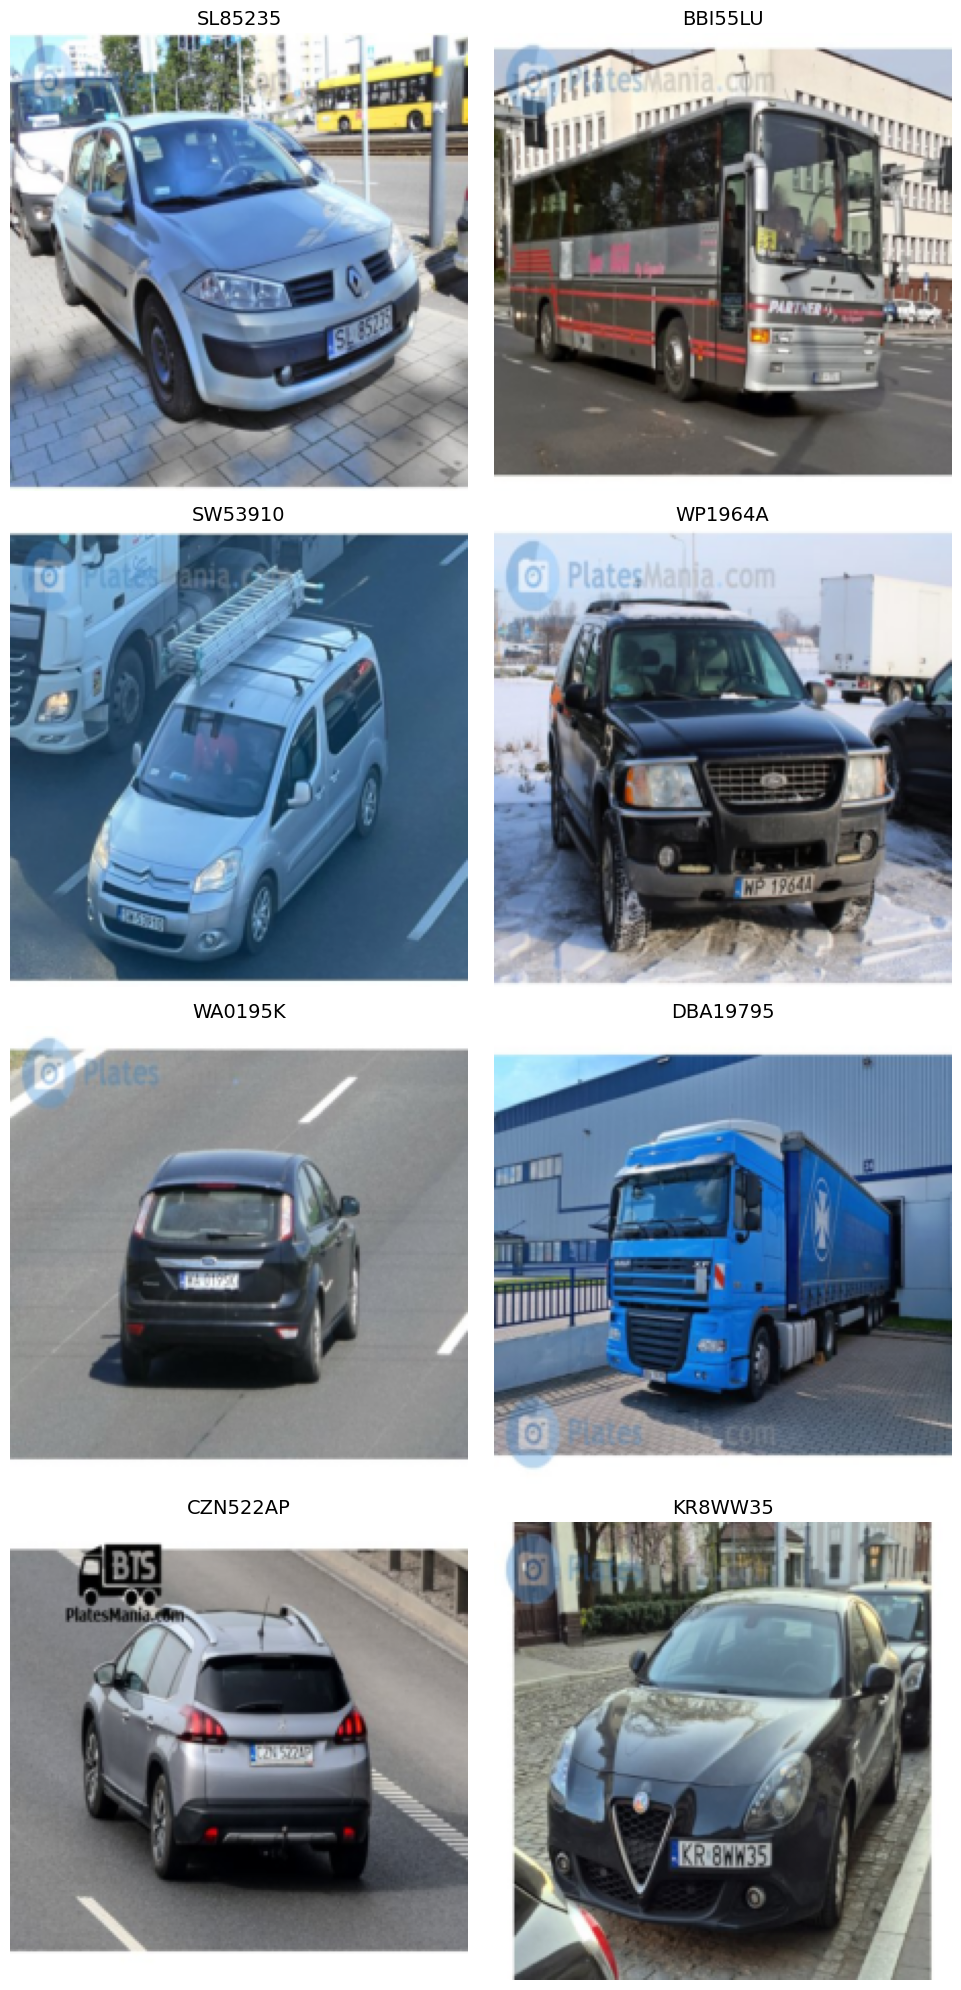

In [19]:
import timm
import torch.nn as nn
import matplotlib.pyplot as plt

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406])
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225])


class PlateClassifier(nn.Module):
    def __init__(self, num_classes: int = NUM_CLASSES, max_len: int = MAX_LEN):
        super().__init__()
        self.backbone = timm.create_model("efficientnet_b0", pretrained=True, num_classes=0)
        self.head = nn.Linear(self.backbone.num_features, max_len * num_classes)
        self.max_len = max_len
        self.num_classes = num_classes

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.backbone(x)   # (B, 1280)
        x = self.head(x)       # (B, max_len * num_classes)
        return x.view(-1, self.max_len, self.num_classes)  # (B, 8, 37)


model = PlateClassifier()
print(f"Output shape: {model(torch.zeros(1, 3, 224, 224)).shape}")  # (1, 8, 37)

# ── preview preprocessed images ──────────────────────────────────────────────
IDX2CHAR = {i: c for c, i in CHAR2IDX.items()}

def _decode(t):
    return "".join(IDX2CHAR.get(i.item(), "") for i in t if i.item() != BLANK)

_dm = PlatesDataModule(batch_size=8)
_dm.setup()
_imgs, _labels = next(iter(_dm.val_dataloader()))

fig, axes = plt.subplots(4, 2, figsize=(10, 20))
for ax, img, lbl in zip(axes.flatten(), _imgs, _labels):
    rgb = (img.permute(1, 2, 0) * IMAGENET_STD + IMAGENET_MEAN).clamp(0, 1).numpy()
    ax.imshow(rgb)
    ax.set_title(_decode(lbl), fontsize=14)
    ax.axis("off")
plt.tight_layout()
plt.show()


In [20]:
from lightning.pytorch.loggers import CometLogger

comet_logger = CometLogger(
    api_key=os.environ.get("COMET_API_KEY"),
    project_name="plate-recognition",
    experiment_name="efficientnet-b0",
)


class PlateModule(L.LightningModule):
    def __init__(self, lr: float = 1e-3):
        super().__init__()
        self.model = PlateClassifier()
        self.lr = lr
        self.loss_fn = nn.CrossEntropyLoss()
        
    def forward(self, x):
        return self.model(x)

    def _step(self, batch):
        imgs, labels = batch
        logits = self(imgs)                                      # (B, 8, 37)
        loss = self.loss_fn(logits.permute(0, 2, 1), labels)
        preds = logits.argmax(-1)                               # (B, 8)
        char_acc  = (preds == labels).float().mean()
        plate_acc = (preds == labels).all(dim=-1).float().mean()  # full plate correct
        return loss, char_acc, plate_acc

    def training_step(self, batch, _):
        loss, char_acc, plate_acc = self._step(batch)
        self.log_dict({
            "train/loss": loss,
            "train/char_acc": char_acc,
            "train/plate_acc": plate_acc,
        }, prog_bar=True)
        return loss

    def validation_step(self, batch, _):
        loss, char_acc, plate_acc = self._step(batch)
        self.log_dict({
            "val/loss": loss,
            "val/char_acc": char_acc,
            "val/plate_acc": plate_acc,
        }, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)


dm = PlatesDataModule(batch_size=64)
module = PlateModule()

trainer = L.Trainer(
    max_epochs=20,
    accelerator="auto",
    precision="16-mixed",
    logger=comet_logger,
)
trainer.fit(module, dm)


The parameter `experiment_name` is deprecated, please use `name` instead.
The parameter `project_name` is deprecated, please use `project` instead.
COMET INFO: An experiment with the same configuration options is already running and will be reused.
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/mamusiaarusia/myenv/lib/python3.12/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not suppo

┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ PlateClassifier  │  4.4 M │ train │     0 │
│ 1 │ loss_fn │ CrossEntropyLoss │      0 │ train │     0 │
└───┴─────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 4.4 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 4.4 M                                                                                                
Total estimated model params size (MB): 17                                                                         
Modules in train mode: 244                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/mamusiaarusia/myenv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

`Trainer.fit` stopped: `max_epochs=20` reached.


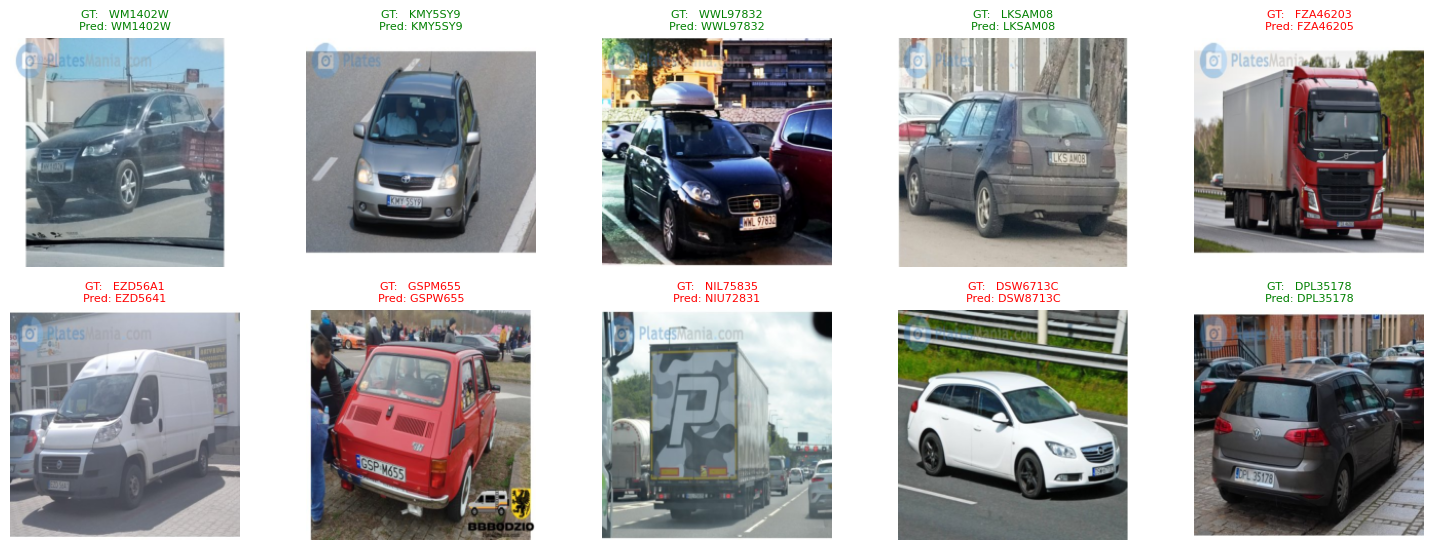

In [23]:
import matplotlib.pyplot as plt

IDX2CHAR = {i: c for c, i in CHAR2IDX.items()}
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406])
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225])

def decode(indices: torch.Tensor) -> str:
    return "".join(IDX2CHAR.get(i.item(), "") for i in indices if i.item() != BLANK)

def show_predictions(model, datamodule, n: int = 10):
    device = next(model.parameters()).device
    model.eval()

    datamodule.setup()
    loader = DataLoader(datamodule.val_ds, batch_size=n, shuffle=True)
    imgs, labels = next(iter(loader))

    with torch.no_grad():
        logits = model(imgs.to(device))        # (n, MAX_LEN, NUM_CLASSES)
    preds = logits.argmax(-1).cpu()            # (n, MAX_LEN)

    cols = 5
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 2.8))
    axes = axes.flatten()

    for i in range(n):
        img = imgs[i].permute(1, 2, 0) * IMAGENET_STD + IMAGENET_MEAN
        img = img.clamp(0, 1).numpy()

        gt   = decode(labels[i])
        pred = decode(preds[i])
        match = pred == gt

        axes[i].imshow(img)
        axes[i].set_title(f"GT:   {gt}\nPred: {pred}", fontsize=8,
                          color="green" if match else "red")
        axes[i].axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_predictions(module.model, dm)
